# 02 ---- Clustering



## 1. Importación y carga de librerías

Importación y carga de librerías.

In [1]:
# Librerías de manipulación de datos.
import pandas as pd 
import numpy as np 

# Librerías de visualización.
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px 

# Librerías de machine learning.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Configuración de librerías
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)


Carga del dataset con el que trabajar.

In [6]:
ruta = '../data/processed/dataset_clean.csv'
df_raw = pd.read_csv(ruta)

print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]}")
print(f"\nColumnas disponibles:\n{list(df_raw.columns)}")

# Trabajamos con una copia del dataset.
df = df_raw.copy()

Filas: 113,422
Columnas: 21

Columnas disponibles:
['artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'duration_min', 'popularity_category']


## 2. Selección y escalado de features

In [7]:
# Features de audio para el clustering. Se excluye poularity, ya que es una etiqueta externa.
features_cluster = ['danceability', 'energy', 'loudness', 'speechiness','acousticness', 'instrumentalness', 'liveness','valence', 'tempo']
X = df[features_cluster].copy()

# Escalado. 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Matrix de features: {X_scaled.shape}")
print(f"\nMedia tras escalado (debe ser ~0):\n{X_scaled.mean(axis=0).round(3)}")
print(f"\nStd tras escalado (debe ser ~1):\n{X_scaled.std(axis=0).round(3)}")

Matrix de features: (113422, 9)

Media tras escalado (debe ser ~0):
[ 0.  0.  0. -0. -0. -0. -0.  0. -0.]

Std tras escalado (debe ser ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 3. Elbow Method

k=2 — Inercia: 140128.7
k=3 — Inercia: 124202.8
k=4 — Inercia: 112578.7
k=5 — Inercia: 101928.9
k=6 — Inercia: 92994.5
k=7 — Inercia: 84909.8
k=8 — Inercia: 79832.1
k=9 — Inercia: 75329.1
k=10 — Inercia: 72167.9
k=11 — Inercia: 69784.9
k=12 — Inercia: 67429.7


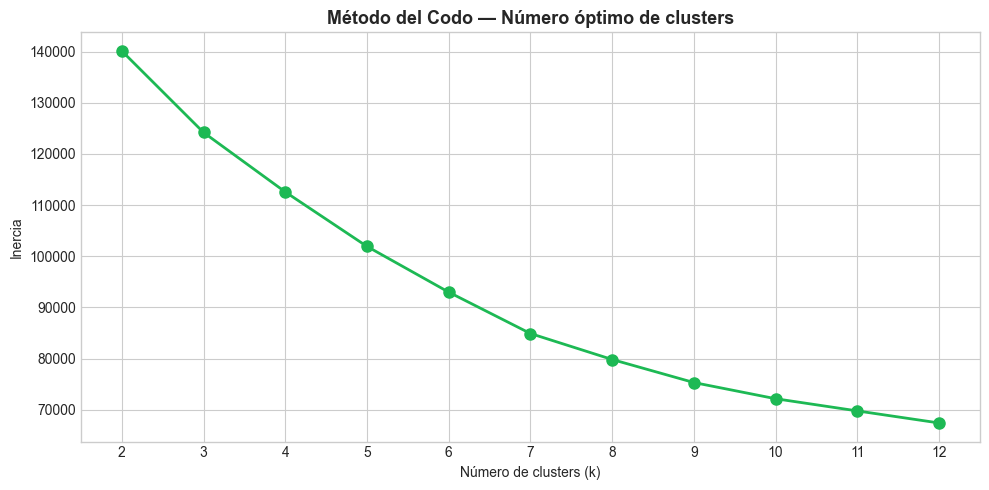

In [8]:
# Usamos una muestra para que sea computacionalmente viable.
np.random.seed(42)
muestra_idx = np.random.choice(len(X_scaled), size=20000, replace=False)
X_muestra = X_scaled[muestra_idx]

inercias = []
rango_k = range(2,13)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_muestra)
    inercias.append(kmeans.inertia_)
    print(f"k={k} — Inercia: {kmeans.inertia_:.1f}")
    
# Configuración del método.
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rango_k, inercias, marker='o', linewidth=2, color='#1DB954', markersize=8)
ax.set_title('Método del Codo — Número óptimo de clusters', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inercia')
ax.set_xticks(list(rango_k))

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('../reports/figures/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

La curva más pronunciada está en k=6, dónde la bajada de inercia empieza a ser más gradual.

## 4. Silhouette Score

k=2 — Silhouette Score: 0.2690
k=3 — Silhouette Score: 0.1645
k=4 — Silhouette Score: 0.1711
k=5 — Silhouette Score: 0.1770
k=6 — Silhouette Score: 0.1872
k=7 — Silhouette Score: 0.1990
k=8 — Silhouette Score: 0.1798
k=9 — Silhouette Score: 0.1849
k=10 — Silhouette Score: 0.1718
k=11 — Silhouette Score: 0.1600
k=12 — Silhouette Score: 0.1624


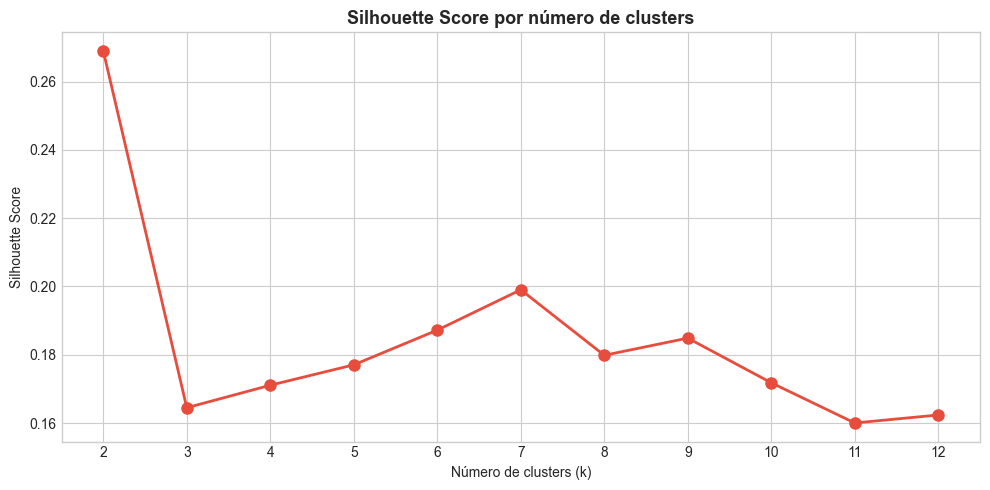

In [9]:
silhouette_scores = []

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_muestra)
    score = silhouette_score(X_muestra, labels, sample_size=5000, random_state=42)
    silhouette_scores.append(score)
    print(f"k={k} — Silhouette Score: {score:.4f}")

# Configuración del gráfico.
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rango_k, silhouette_scores, marker='o', linewidth=2, color='#E74C3C', markersize=8)
ax.set_title('Silhouette Score por número de clusters', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_xticks(list(rango_k))

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('../reports/figures/silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()

El mejor score ignorando k=2 (demasiado simple) es k=7 con 0.1990. Elegiremos k=7 como equilibrio entre interpretalidad y calidad de clustering.

## 5. Entrenamiento K-Means final con k=7

In [10]:
k_optimo = 7

kmeans_final = KMeans(n_clusters=k_optimo , random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Clustering completado con k={k_optimo} ")
print(f"\nDistribución de canciones por cluster:")
distribucion = df['cluster'].value_counts().sort_index()
for cluster, count in distribucion.items():
    print(f"  Cluster {cluster}: {count:,} canciones ({count/len(df)*100:.1f}%)")

Clustering completado con k=7 

Distribución de canciones por cluster:
  Cluster 0: 7,749 canciones (6.8%)
  Cluster 1: 22,865 canciones (20.2%)
  Cluster 2: 7,282 canciones (6.4%)
  Cluster 3: 36,337 canciones (32.0%)
  Cluster 4: 11,702 canciones (10.3%)
  Cluster 5: 26,375 canciones (23.3%)
  Cluster 6: 1,112 canciones (1.0%)


Perfil de cada cluster

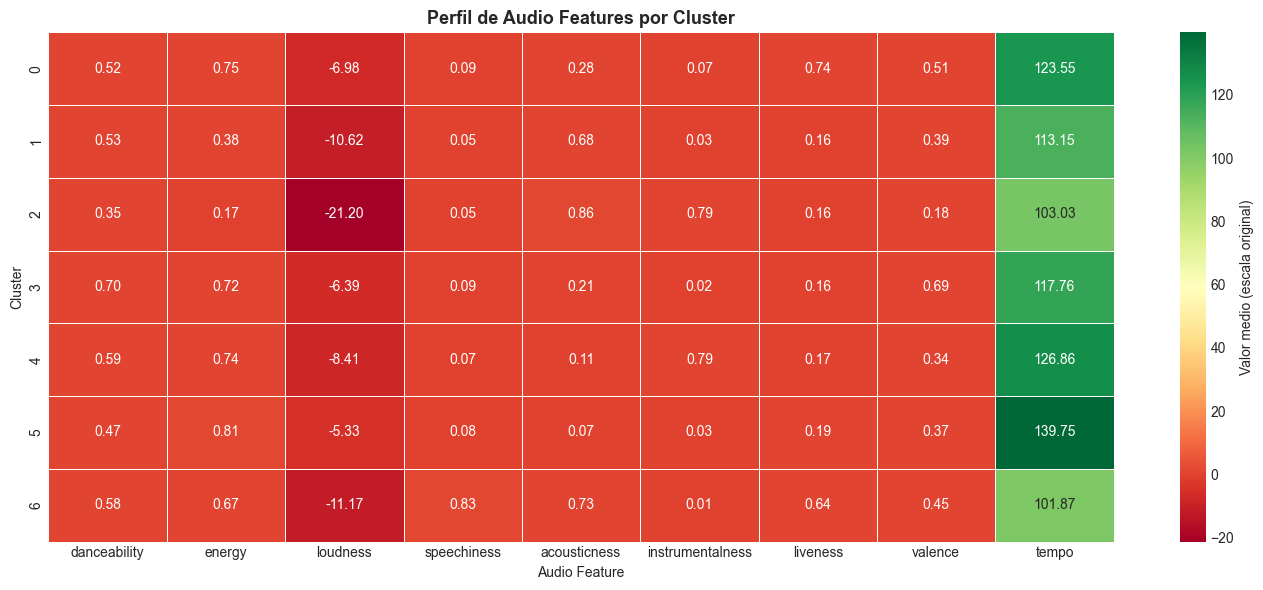

         danceability  energy  loudness  speechiness  acousticness  instrumentalness  liveness  valence    tempo
cluster                                                                                                         
0               0.524   0.754    -6.981        0.087         0.283             0.065     0.737    0.513  123.549
1               0.532   0.377   -10.621        0.053         0.678             0.029     0.158    0.393  113.153
2               0.346   0.170   -21.198        0.051         0.865             0.787     0.163    0.184  103.026
3               0.705   0.722    -6.387        0.093         0.208             0.018     0.164    0.693  117.759
4               0.587   0.741    -8.413        0.071         0.112             0.790     0.170    0.340  126.858
5               0.472   0.814    -5.334        0.083         0.075             0.033     0.192    0.372  139.748
6               0.576   0.666   -11.170        0.828         0.728             0.010     0.643  

In [11]:
# Selección de perfiles.
perfil_clusters = df.groupby('cluster')[features_cluster].mean().round(3)

# Configuración de gráficos.
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(perfil_clusters,annot=True,fmt='.2f',cmap='RdYlGn',ax=ax,linewidths=0.5,cbar_kws={'label': 'Valor medio (escala original)'})
ax.set_title('Perfil de Audio Features por Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Audio Feature')
ax.set_ylabel('Cluster')

# Mostrar gráficos.
plt.tight_layout()
plt.savefig('../reports/figures/perfil_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print(perfil_clusters.to_string())

De estos resultados, podemos crear algunas etiquetas con bastante confianza.

| Clúster | Características Dominantes | Nombre Propuesto |
| ------| ---------------------------|------------------|
|   0   | Tempo medio, alta energy y liveness | **Conciertos en vivo** |
|   1   | Alta acousticness, bajo liveness y energy | **Acústico y tranquilo** |
|   2   | Acousticness muy alta, instrumentalness alta, baja energy | **Instrumental clásico** |
|   3   | Alta danceability, energy y valence | **Fiesta y baile** |
|   4   | Alta instrumentalness y energy | **Electrónico instrumental** |
|   5   | Máxima energy, tempo y loudness muy alto | **Rock e intenso** |
|   6   | Muy alto speechiness, alta acousticness y liveness | **Rap** |